In [3]:
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver


print("=" * 60)
print("VQE for H2 Molecule on simulator")
print("=" * 60)

# ---- Step 1: Generate N2 Hamiltonian ----
print("\n[1/5] Generating H2 Hamiltonian...")
driver = PySCFDriver(atom='H 0 0 0; H 0 0 0.735', basis='sto3g')
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"  ✓ Number of qubits: {hamiltonian.num_qubits}")
print(f"  ✓ Number of Pauli terms: {len(hamiltonian)}")

VQE for H2 Molecule on simulator

[1/5] Generating H2 Hamiltonian...
  ✓ Number of qubits: 4
  ✓ Number of Pauli terms: 15


In [4]:
from scipy.sparse.linalg import eigsh

# Sparse reprezentace
hamiltonian_sparse = hamiltonian.to_matrix(sparse=True)

# Najdi nejnižší vlastní hodnotu
eigenvalues, eigenvectors = eigsh(hamiltonian_sparse, k=1, which='SA')
ground_state_energy = eigenvalues[0]

print(f"Ground state energy: {ground_state_energy} Ha")
print(f"Ground state vector shape: {eigenvectors.shape}")

expected_energy = ground_state_energy + problem.nuclear_repulsion_energy
print(f"Expected total energy (including nuclear repulsion): {expected_energy} Ha")

Ground state energy: -1.8572750302023837 Ha
Ground state vector shape: (16, 1)
Expected total energy (including nuclear repulsion): -1.137306035753404 Ha


This circuit has  8 parameters


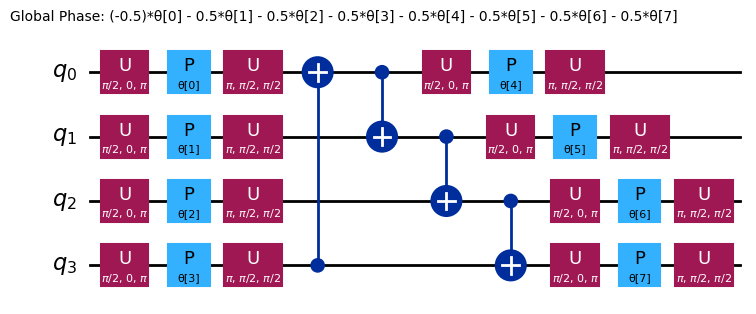

In [3]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
 
# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
 
ansatz.decompose().draw("mpl", style="iqp")

In [4]:
from scipy.optimize import minimize
import numpy as np

import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)


from methods.methods import cost_function


iterations = [0]
file_name = "h2-one-rep.csv"
initial_params = np.zeros(ansatz.num_parameters)

print("Optimizing parameters...")
result = minimize(
    fun=cost_function, 
    x0=initial_params, 
    args=(problem, hamiltonian, ansatz, file_name, iterations),
    method='COBYLA', 
    options={"maxiter": 20_000}
)

print("-" * 30)
print(f"Optimized energy: {result.fun:.6f} Ha")
print(f"Expected:         {expected_energy} Ha")


Optimizing parameters...
Iteration 1: Evaluating cost function...
  Energy: 0.366644 Ha
Iteration 2: Evaluating cost function...
  Energy: 0.203376 Ha
Iteration 3: Evaluating cost function...
  Energy: 0.141532 Ha
Iteration 4: Evaluating cost function...
  Energy: 0.086766 Ha
Iteration 5: Evaluating cost function...
  Energy: -0.001376 Ha
Iteration 6: Evaluating cost function...
  Energy: -0.001376 Ha
Iteration 7: Evaluating cost function...
  Energy: -0.001376 Ha
Iteration 8: Evaluating cost function...
  Energy: -0.017433 Ha
Iteration 9: Evaluating cost function...
  Energy: -0.001376 Ha
Iteration 10: Evaluating cost function...
  Energy: -0.163105 Ha
Iteration 11: Evaluating cost function...
  Energy: 0.283316 Ha
Iteration 12: Evaluating cost function...
  Energy: -0.017438 Ha
Iteration 13: Evaluating cost function...
  Energy: -0.097971 Ha
Iteration 14: Evaluating cost function...
  Energy: -0.350444 Ha
Iteration 15: Evaluating cost function...
  Energy: -0.271561 Ha
Iteration 16: 

In [5]:
from methods.methods import compute_error
error = compute_error(result.fun, expected_energy)
print(f"Relative error:   {error:.2f}%")

Relative error:   1.79%


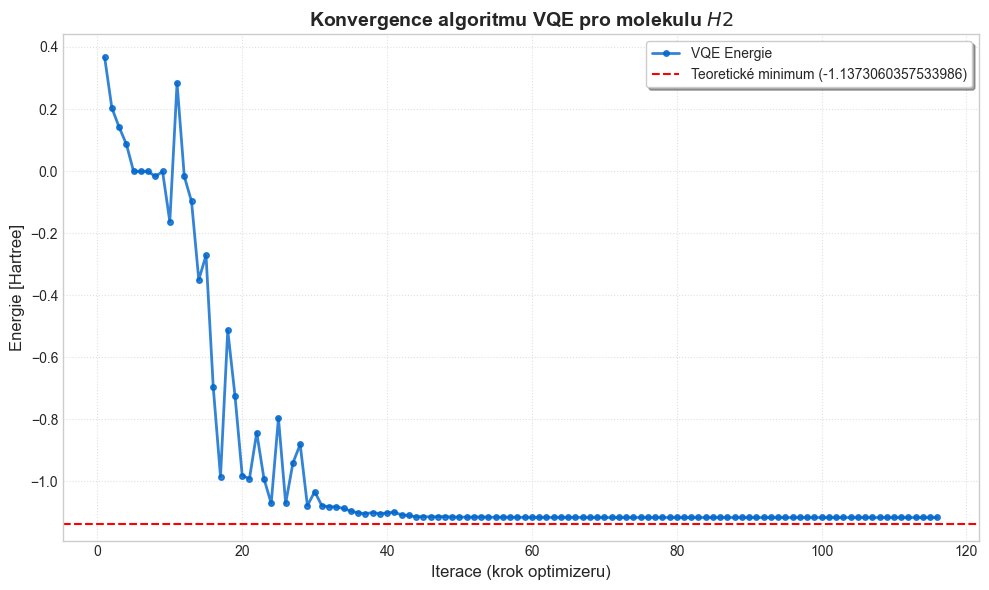

In [8]:
from methods.methods import plot_convergence
plot_convergence(file_name, 'H2', expected_energy)

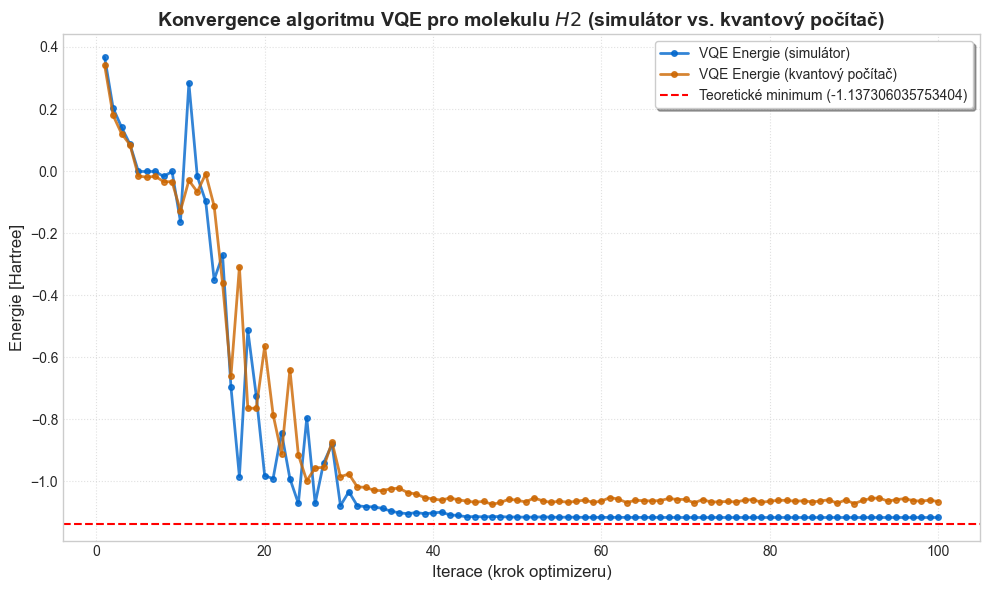

In [6]:
import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from methods.methods import plot_convergence_simulator_qc
plot_convergence_simulator_qc('h2-one-rep.csv', 'qc_h2.csv','H2', expected_energy)